In [1]:
!pip install numpy pandas matplotlib tensorflow

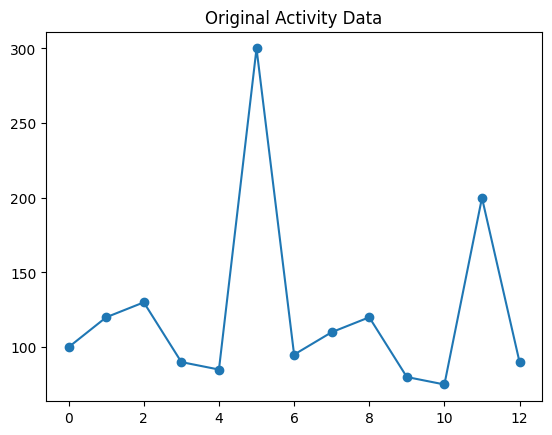

In [3]:
import numpy as np
import matplotlib.pyplot as plt


data = np.array([100,120,130,90,85,300,95,110,120,80,75,200,90])

plt.plot(data, marker='o')
plt.title("Original Activity Data")
plt.show()

In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.reshape(-1,1))

X = []
y = []

for i in range(len(data_scaled)-3):
    X.append(data_scaled[i:i+3])
    y.append(data_scaled[i+3])

X = np.array(X)
y = np.array(y)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(3,1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.fit(X, y, epochs=100, verbose=0)

print("✅ Model trained")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


✅ Model trained


In [7]:
predictions = model.predict(X)
predictions = scaler.inverse_transform(predictions)
y_actual = scaler.inverse_transform(y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step


In [8]:
errors = abs(predictions.flatten() - y_actual.flatten())

threshold = 50  # simple rule
anomalies = errors > threshold

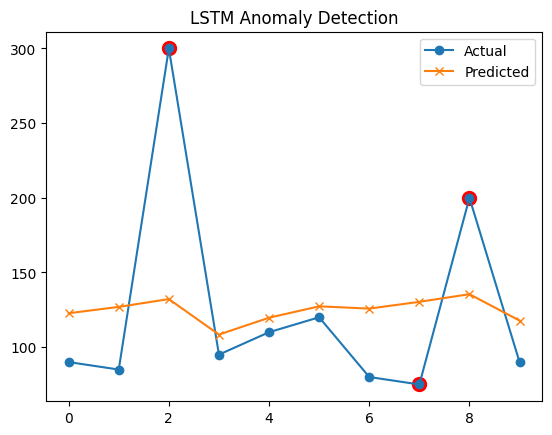

In [9]:
plt.figure()

plt.plot(y_actual, label="Actual", marker='o')
plt.plot(predictions, label="Predicted", marker='x')

# mark anomalies
for i in range(len(anomalies)):
    if anomalies[i]:
        plt.scatter(i, y_actual[i], color='red', s=100)

plt.legend()
plt.title("LSTM Anomaly Detection")
plt.show()